This notebook produces simulations for assessing how power (TPR) changes as a function of CRE_oi (oi = "of interest") strength, for the hypothesis "CRE_oi is significantly different from minP".

In a simulation
- The number of cells changes the power (naturally: more samples or less samples)
- The number of unique CREs also hanges the power: for a fixed MOI, a library with more elements will have less representation of each element.

This means that we can't just manipulate these freely.

Realistically, CRE_oi vs minP will be done within one cell-type. I'll choose "reference" (PSCs)

With this in mind, we'll

1. Draw n CREs from a log uniform distribution spanning from 0 to the max CRE strength, for n=number of CREs detected in PSCs
2. Add a reference CRE
3. simulate m cells, where m is the number of PSCs in the original dataset, across 5 replicates
4. Then for each replicate we calculate mwu
5. Repeat 1-4 5x times...

Then we summarize performance
1. load all the results DF
2. drop everything except cre_oi and T/F call
3. bin / plot

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
from pathlib import Path
import numpy as np
import uuid
import pandas as pd

2026-02-03 18:12:13.402983: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-03 18:12:13.406821: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [2]:
data_root=Path("/nfs/roberts/project/pi_skr2/shared/tabula_data")

In [3]:
local=False
if local:
    cluster=LocalCluster(memory_limit='48G')
    client=Client(cluster)
else:
    cluster=SLURMCluster(
        cores=3,#cores per slurm job
        memory="16G",#memory per slurm job
        processes=1,#dask workers per slurm job,
        job_extra_directives=["-p day", 
            f"--job-name=simclust_worker",
            f"--time=6:00:00",
            f"--output=worker_%j.out"]
    )
    #cluster.scale(jobs=20)
    cluster.scale(jobs=9)
    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )

In [4]:
#copy the bounds
bound=scm.SHENDURE_BOUNDS.copy()
#we are only simulating one cell type 
bound.cells_per_cell_type=scm.SHENDURE_BOUNDS.cells_per_cell_type.loc[["reference"]]

In [5]:
primordial=scm.ortho.load(client,data_root/"shendure","ortho_primordial_v4")
dat=primordial.training_data.data
n_cres=len(dat[dat["cell_type"]=="reference"]["cre_id"].unique())
del primordial

In [ ]:
max=0.05
min=scm.SHENDURE_BOUNDS.min_mpra_umi
#cells=scm.SHENDURE_BOUNDS.cells_per_cell_type["reference"]
minP=scm.SHENDURE_BOUNDS.reference_activity

In [62]:
minP

0.019310843914603474

In [ ]:
names=[]
sims=[]
for i in range(100):
    name, sim = scm.one_library_replicate(root=data_root/"2026-02-03_shendure_pow",
        n_sims=5,
        client=client,
        flatten_overtransfection=False,
        bound=bound,
        n_cres=n_cres,
        min=min,
        max=max,
        n_cres=n_cres,
        minP=minP)
    sims.append(sim)
    names.append(name)


scMPRAforge: INFO: No 'state.parquet' found for 'sim_2a67f0e0'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_f1ebece9'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_a008e89d'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_1d3e0428'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_d7e77520'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_159be077'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_38e6ef06'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_84e205fd'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_110280c5'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_7cdbddfa'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_6930e157'. Initalizing new object.
scMPRAforge: INFO: No 'state.par

In [9]:
for sim in sims:
    sim.save()

In [10]:
sims[0].ground_truth

,cre_id,mu,cell_type
0,synthcre_0,0.043117,reference
1,synthcre_1,0.031492,reference
2,synthcre_2,0.034569,reference
3,synthcre_3,0.004496,reference
4,synthcre_4,0.044187,reference
...,...,...,...
202,synthcre_202,0.024960,reference
203,synthcre_203,0.033936,reference
204,synthcre_204,0.028013,reference
205,synthcre_205,0.047080,reference


In [11]:
example_data=scm.scMPRA_data.from_parquet(sims[0].scmpradatp/"0.scmpra")
example_data

In [12]:
hs_all_ct = scm.make_all_by_celltype_hypotheses(
    counts=example_data,
    reference_cre="reference",
)

In [13]:
for sim in sims:
    sim.add_hypothesis_set("hs_all_ct",hs_all_ct)
    sim.mwu("hs_all_ct")

for sim in sims:
    sim.save()

In [ ]:
mergy=scm.sum_pow(sims=sims,hypothesis_set_name="hs_all_ct",test_type="mwu")

In [31]:
mergy

,reject_null,fc
0,True,2.513413
1,True,2.143467
2,False,0.986085
3,True,0.224871
4,True,0.372796
...,...,...
201,True,1.824368
202,True,0.192210
203,False,0.991631
204,False,0.760933


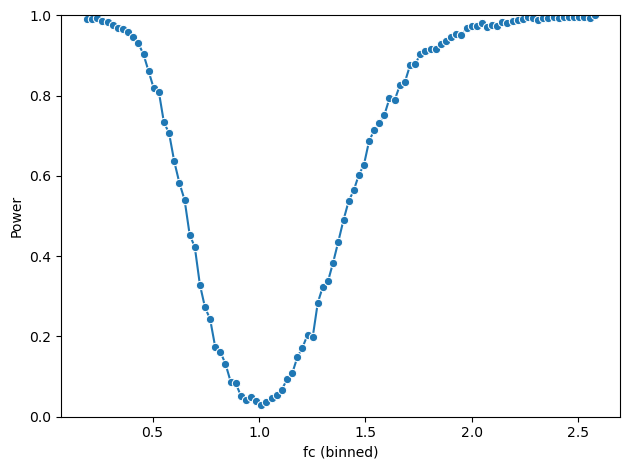

In [ ]:
scm.pow_curve(mergy,n_bins=100)

In [36]:
client.close()
cluster.close()